In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.utils import shuffle
from skimage.transform import resize
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential,layers
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
aphids = glob.glob('Cotton plant disease/Aphids edited/*.jpg')
army_worm =  glob.glob('Cotton plant disease/Army worm edited/*.jpg')
bacterial_blight =  glob.glob('Cotton plant disease/Bacterial Blight edited/*.jpg')
healthy_leaf = glob.glob('Cotton plant disease/Healthy leaf edited/*.jpg')
powerdy_mildew = glob.glob('Cotton plant disease/Powdery Mildew Edited/*.jpg')
target_spot = glob.glob('Cotton plant disease/Target spot edited/*.jpg')

In [3]:
len(aphids)

39

In [4]:
len(army_worm)

40

In [5]:
len(bacterial_blight)

40

In [6]:
len(healthy_leaf)

38

In [7]:
len(powerdy_mildew)

38

In [8]:
len(target_spot)

39

In [9]:
classes = {0 : 'aphids', 1 : 'army_worm', 2 : 'bacterial_Blight', 3 : 'healthy_leaf', 4 : 'powerdy_mildew', 5 : 'target_spot'}

In [10]:
images = []
labels = []

for i in aphids:
    img = plt.imread(i)
    images.append(img)
    labels.append(0)

for i in army_worm:
    img = plt.imread(i)
    images.append(img)
    labels.append(1)

for i in bacterial_blight:
    img = plt.imread(i)
    images.append(img)
    labels.append(2)

for i in healthy_leaf:
    img = plt.imread(i)
    images.append(img)
    labels.append(3)

for i in powerdy_mildew:
    img = plt.imread(i)
    images.append(img)
    labels.append(4)

for i in target_spot:
    img = plt.imread(i)
    images.append(img)
    labels.append(5)

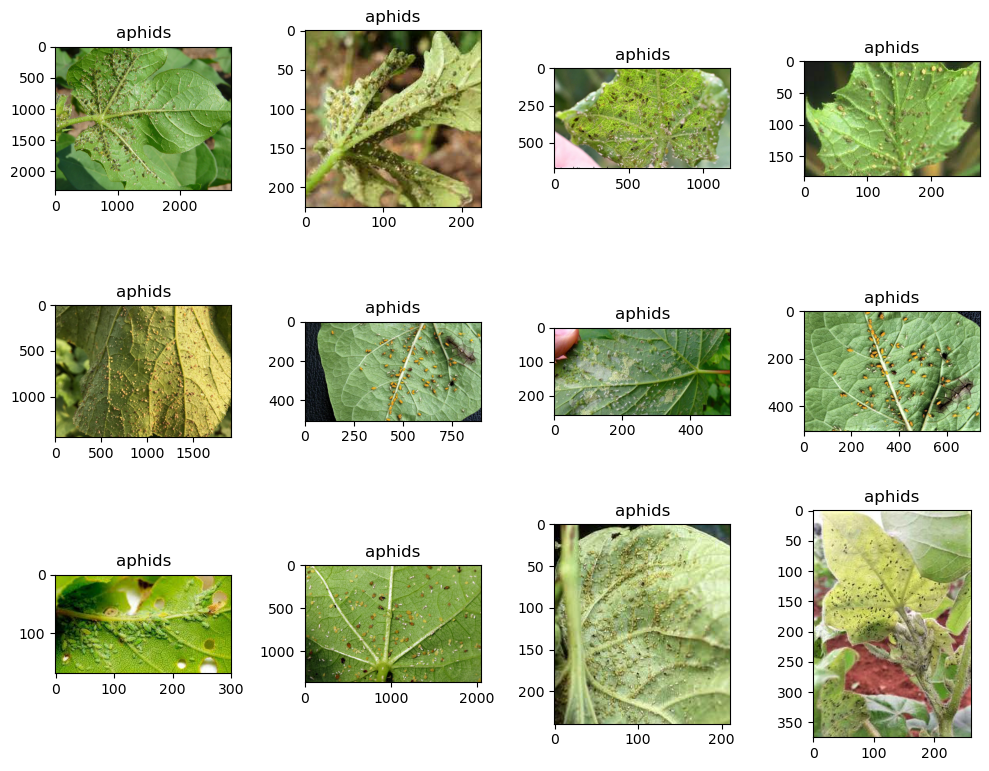

In [11]:
plt.figure(figsize=(10,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(classes[labels[i]])

plt.tight_layout()

In [12]:
images,labels = shuffle(images,labels)

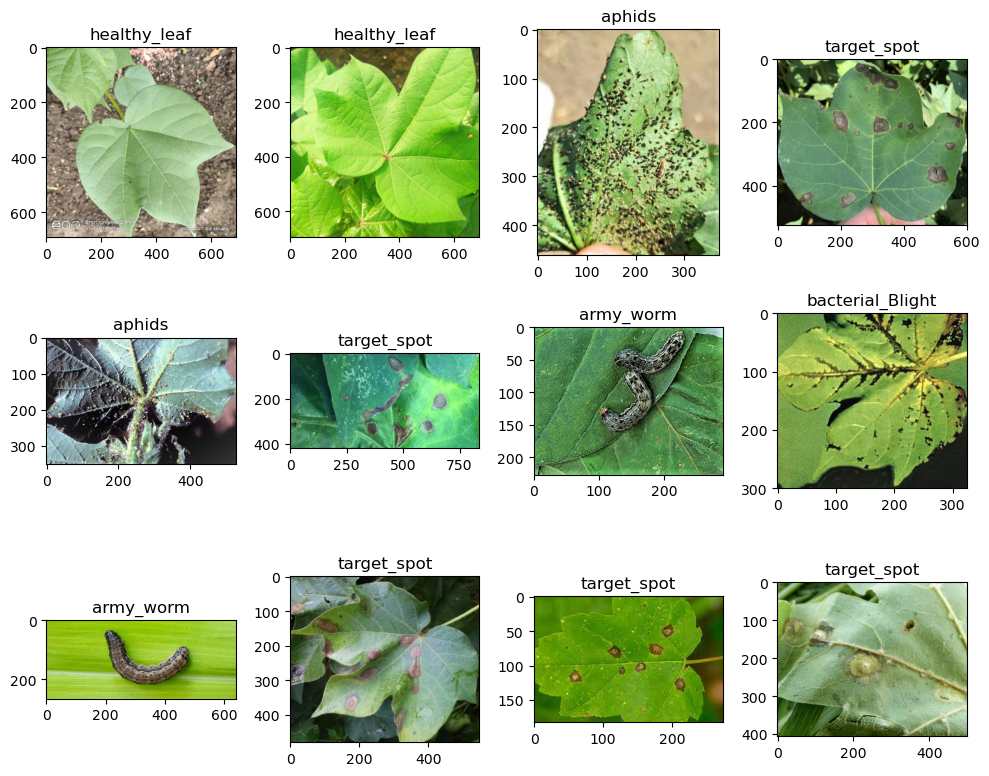

In [13]:
plt.figure(figsize=(10,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(classes[labels[i]])

plt.tight_layout()

In [14]:
for i in range(10):
    print(images[i].shape)

(691, 691, 3)
(694, 694, 3)
(461, 372, 3)
(526, 601, 3)
(351, 527, 3)
(419, 838, 3)
(227, 291, 3)
(301, 325, 3)
(266, 640, 3)
(480, 548, 3)


In [15]:
X = []

for i in images:
    X.append(resize(i,(224,224,3)))

In [16]:
X = np.array(X)
y = np.array(labels)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [19]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

In [20]:
import tensorflow_hub as hub

In [21]:
num_of_classes = 6

In [22]:
pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model,input_shape=(224,224,3),trainable=False
)

In [23]:
model = Sequential([
    layers.InputLayer(input_shape=(224,224,3)),
    layers.Lambda(lambda x: pretrained_model_without_top_layer(x)),

    layers.Dense(64,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(64,activation ='relu'),
    layers.Dense(num_of_classes,activation='softmax')
])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [24]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [25]:
model.fit(X_train,y_train,epochs=10,batch_size=16,validation_split=0.05)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 589ms/step - accuracy: 0.2034 - loss: 1.9151 - val_accuracy: 0.5000 - val_loss: 1.3223
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step - accuracy: 0.5480 - loss: 1.2948 - val_accuracy: 0.8000 - val_loss: 0.8441
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step - accuracy: 0.6497 - loss: 1.0104 - val_accuracy: 0.9000 - val_loss: 0.5850
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.7232 - loss: 0.7999 - val_accuracy: 0.9000 - val_loss: 0.3647
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 367ms/step - accuracy: 0.8023 - loss: 0.6269 - val_accuracy: 0.9000 - val_loss: 0.3827
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - accuracy: 0.8249 - loss: 0.5596 - val_accuracy: 1.0000 - val_loss: 0.3004
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 368ms/step - accuracy: 0.8475 - loss: 0.4520 - val_accuracy: 1.0000 - val_loss: 0.2165
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 367ms/step - accuracy: 0.8870 - loss: 0.3604 - val_accuracy: 0

In [26]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


In [27]:
y_pred = [np.argmax(i) for i in y_pred]

In [28]:
accuracy_score(y_test,y_pred)

0.9148936170212766

In [29]:
confusion_matrix(y_test,y_pred)

array([[10,  0,  0,  0,  0,  2],
       [ 0,  6,  1,  0,  0,  0],
       [ 0,  0,  6,  0,  1,  0],
       [ 0,  0,  0,  4,  0,  0],
       [ 0,  0,  0,  0,  8,  0],
       [ 0,  0,  0,  0,  0,  9]], dtype=int64)

<Axes: >

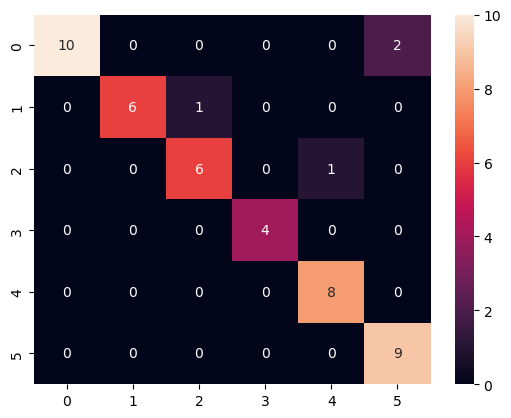

In [30]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')

In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       1.00      0.86      0.92         7
           2       0.86      0.86      0.86         7
           3       1.00      1.00      1.00         4
           4       0.89      1.00      0.94         8
           5       0.82      1.00      0.90         9

    accuracy                           0.91        47
   macro avg       0.93      0.92      0.92        47
weighted avg       0.92      0.91      0.91        47

